In [1]:
from pathlib import Path
import duckdb
import pandas as pd

class DataHubReader:
    def __init__(self, db_name="bronze_company.db"):
        """
        Stellt Verbindung zur DuckDB her.
        Erwartet dieselbe Ordnerstruktur wie DataHub.
        """
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data" / db_name

        if not db_path.exists():
            raise FileNotFoundError(f"Datenbank nicht gefunden: {db_path}")

        self.con = duckdb.connect(str(db_path))

    def _fetch_table(self, table_name: str) -> pd.DataFrame:
        """Generische Methode zum Laden einer Tabelle."""
        return self.con.execute(f"SELECT * FROM {table_name}").df()

    def get_financials(self) -> pd.DataFrame:
        """Yahoo Finance Financials"""
        return self._fetch_table("bronze_financials")

    def get_wikidata(self) -> pd.DataFrame:
        """Wikidata Unternehmensdaten"""
        return self._fetch_table("bronze_wikidata")

    def get_GMD(self) -> pd.DataFrame:
        """Global Macro Database"""
        return self._fetch_table("bronze_gmd")

    def get_interest(self) -> pd.DataFrame:
        """IMF Zinsdaten"""
        return self._fetch_table("bronze_interest")

    def get_commodity(self) -> pd.DataFrame:
        """IMF Commodity Daten"""
        return self._fetch_table("bronze_commodities")
    
    def get_fx_rates(self) -> pd.DataFrame:
        return self._fetch_table("bronze_fx_rates")
    
    def close(self):
        """Schließt die Datenbankverbindung."""
        self.con.close()

In [41]:
fxrates = DataHubReader().get_fx_rates()
fxrates[fxrates['base_currency' ] == 'HKD']

,base_currency,quote_currency,date,rate,ingested_at
25952,HKD,USD,2006-06-08,0.128848,2026-06-08 13:35:07.007217
25953,HKD,USD,2006-06-09,0.128932,2026-06-08 13:35:07.007217
25954,HKD,USD,2006-06-12,0.128848,2026-06-08 13:35:07.007217
25955,HKD,USD,2006-06-13,0.128831,2026-06-08 13:35:07.007217
25956,HKD,USD,2006-06-14,0.128839,2026-06-08 13:35:07.007217
...,...,...,...,...,...
31131,HKD,USD,2026-06-02,0.127600,2026-06-08 13:35:07.007217
31132,HKD,USD,2026-06-03,0.127601,2026-06-08 13:35:07.007217
31133,HKD,USD,2026-06-04,0.127620,2026-06-08 13:35:07.007217
31134,HKD,USD,2026-06-05,0.127644,2026-06-08 13:35:07.007217


In [43]:
financ = DataHubReader().get_financials()
financ[financ['unit'] == 'HKD']

,ticker,date,affiliation,item_description,value,unit,ingested_at
5747984,MLEAS.PA,2024-03-31,balance_sheet,OrdinarySharesNumber,1.818300e+06,HKD,2026-06-08 11:06:01.523604
5747985,MLEAS.PA,2024-03-31,balance_sheet,ShareIssued,1.818300e+06,HKD,2026-06-08 11:06:01.523604
5747986,MLEAS.PA,2024-03-31,balance_sheet,TotalDebt,3.117690e+05,HKD,2026-06-08 11:06:01.523604
5747987,MLEAS.PA,2024-03-31,balance_sheet,TangibleBookValue,-5.325444e+06,HKD,2026-06-08 11:06:01.523604
5747988,MLEAS.PA,2024-03-31,balance_sheet,InvestedCapital,-3.179736e+06,HKD,2026-06-08 11:06:01.523604
...,...,...,...,...,...,...,...
9873062,9999.HK,2026-05-01,price_history,Open,1.844637e+02,HKD,2026-06-08 13:34:03.803698
9873064,9999.HK,2026-06-01,price_history,Close,1.877000e+02,HKD,2026-06-08 13:34:03.803698
9873065,9999.HK,2026-06-01,price_history,High,1.986000e+02,HKD,2026-06-08 13:34:03.803698
9873066,9999.HK,2026-06-01,price_history,Low,1.873000e+02,HKD,2026-06-08 13:34:03.803698


In [2]:
reader = DataHubReader()
df = reader.get_financials()
reader.close()
df



,ticker,date,affiliation,item_description,value,unit,ingested_at
0,AAL,2025-12-31,balance_sheet,TreasurySharesNumber,NaN,USD,2026-06-08 08:05:27.291865
1,AAL,2025-12-31,balance_sheet,OrdinarySharesNumber,6.603011e+08,USD,2026-06-08 08:05:27.291865
2,AAL,2025-12-31,balance_sheet,ShareIssued,6.603011e+08,USD,2026-06-08 08:05:27.291865
3,AAL,2025-12-31,balance_sheet,NetDebt,2.824000e+10,USD,2026-06-08 08:05:27.291865
4,AAL,2025-12-31,balance_sheet,TotalDebt,3.688400e+10,USD,2026-06-08 08:05:27.291865
...,...,...,...,...,...,...,...
9877567,89988.HK,2026-06-01,price_history,Close,1.028000e+02,CNY,2026-06-08 13:35:03.809133
9877568,89988.HK,2026-06-01,price_history,High,1.131000e+02,CNY,2026-06-08 13:35:03.809133
9877569,89988.HK,2026-06-01,price_history,Low,1.020000e+02,CNY,2026-06-08 13:35:03.809133
9877570,89988.HK,2026-06-01,price_history,Open,1.059000e+02,CNY,2026-06-08 13:35:03.809133


In [3]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional
import pandas as pd
import numpy as np

@dataclass
class YahooFinanceValidator:
    """
    Validiert und harmonisiert Yahoo-Financials-Daten.

    Erwartete Spalten:
    ticker | date | affiliation | item_description | value | ingested_at
    """

    ticker_col: str = "ticker"
    date_col: str = "date"
    affiliation_col: str = "affiliation"
    item_description_col: str = "item_description"
    value_col: str = "value"
    ingested_at_col: str = "ingested_at"

    def validate(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Führt die Typ-Harmonisierung auf allen relevanten Spalten durch.
        Nicht konvertierbare Werte werden zu NaN / NaT.
        """
        self._validate_required_columns(df)

        out = df.copy()

        out[self.ticker_col] = self._to_string_series(out[self.ticker_col])
        out[self.date_col] = self._to_timestamp_series(out[self.date_col])
        out[self.affiliation_col] = self._to_string_series(out[self.affiliation_col])
        out[self.item_description_col] = self._to_string_series(out[self.item_description_col])
        out[self.value_col] = self._to_float_series(out[self.value_col])

        if self.ingested_at_col in out.columns:
            out[self.ingested_at_col] = self._to_timestamp_series(out[self.ingested_at_col])

        return out

    def _validate_required_columns(self, df: pd.DataFrame) -> None:
        required = {
            self.ticker_col,
            self.date_col,
            self.affiliation_col,
            self.item_description_col,
            self.value_col,
            self.ingested_at_col,
        }
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"Fehlende Spalten im DataFrame: {sorted(missing)}")

    @staticmethod
    def _to_string_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in Strings um.
        Falls ein Wert nicht sinnvoll konvertierbar ist, wird <NA> gesetzt.

        Hinweis:
        Fast alles ist in Python zu str(...) konvertierbar.
        Problematische Fälle wie None/NaN/leere Strings werden als fehlend markiert.
        """
        def convert(value: object) -> Optional[str]:
            if pd.isna(value):
                return pd.NA
            try:
                text = str(value).strip()
                if text == "":
                    return pd.NA
                return text
            except Exception:
                return pd.NA

        return series.map(convert).astype("string")

    @staticmethod
    def _to_timestamp_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in pandas Timestamps um.
        Nicht konvertierbare Werte werden zu NaT.
        """
        return pd.to_datetime(series, errors="coerce")

    @staticmethod
    def _to_float_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in float64 um.
        Nicht konvertierbare Werte werden zu NaN.

        float64 ist für GNN/ML-Pipelines meist die richtige Wahl.
        """
        numeric = pd.to_numeric(series, errors="coerce")
        return numeric.astype("float64")

    def report_invalid_counts(self, df_before: pd.DataFrame, df_after: pd.DataFrame) -> pd.DataFrame:
        """
        Erstellt einen kleinen Report, wie viele fehlende Werte nach der Validierung
        in den relevanten Spalten vorliegen.
        """
        cols = [
            self.ticker_col,
            self.date_col,
            self.affiliation_col,
            self.item_description_col,
            self.value_col,
            self.ingested_at_col,
        ]

        rows = []
        for col in cols:
            before_missing = df_before[col].isna().sum()
            after_missing = df_after[col].isna().sum()
            rows.append({
                "column": col,
                "missing_before": int(before_missing),
                "missing_after": int(after_missing),
                "new_missing_created": int(after_missing - before_missing),
            })

        return pd.DataFrame(rows)

In [4]:
df_after = YahooFinanceValidator().validate(df)

In [5]:
YahooFinanceValidator().report_invalid_counts(df, df_after)

,column,missing_before,missing_after,new_missing_created
0,ticker,0,0,0
1,date,0,0,0
2,affiliation,0,0,0
3,item_description,0,0,0
4,value,1270688,1270688,0
5,ingested_at,0,0,0


In [6]:
from __future__ import annotations
from typing import Optional, Sequence
import pandas as pd

class YahooFinanceDuplicateChecker:
    """
    Prüft und behandelt Duplikate in Yahoo-Financials-Long-Format.

    Standard-Naturschlüssel:
    ["ticker", "date", "affiliation", "item_description"]
    """

    DEFAULT_SUBSET = ["ticker", "date", "affiliation", "item_description"]

    def __init__(self, subset: Optional[Sequence[str]] = None):
        self.subset = list(subset) if subset is not None else self.DEFAULT_SUBSET.copy()

    def _validate_subset(self, df: pd.DataFrame, subset: Optional[Sequence[str]] = None) -> list[str]:
        use_subset = list(subset) if subset is not None else self.subset
        missing = [col for col in use_subset if col not in df.columns]
        if missing:
            raise ValueError(f"Fehlende Spalten für Duplicate-Check: {missing}")
        return use_subset

    def find_exact_duplicates(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Gibt alle Zeilen zurück, die exakte Duplikate kompletter Zeilen sind.
        Alle betroffenen Zeilen werden zurückgegeben (keep=False).
        """
        mask = df.duplicated(keep=False)
        return df.loc[mask].copy()

    def find_key_duplicates(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None
    ) -> pd.DataFrame:
        """
        Gibt alle Zeilen zurück, die bezüglich des natürlichen Schlüssels dupliziert sind.

        Standardmäßig:
        ["ticker", "date", "affiliation", "item_description"]

        Beispiel:
        Zwei Zeilen mit gleichem ticker/date/affiliation/item_description,
        aber unterschiedlichem value oder ingested_at, werden hier gefunden.
        """
        use_subset = self._validate_subset(df, subset)
        mask = df.duplicated(subset=use_subset, keep=False)
        return df.loc[mask].copy()

    def drop_duplicates(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None,
        keep: str = "first"
    ) -> pd.DataFrame:
        """
        Entfernt Duplikate anhand des natürlichen Schlüssels oder eines übergebenen Subsets.

        keep:
        - "first": erste Zeile behalten
        - "last": letzte Zeile behalten
        - False: alle Duplikat-Gruppen komplett entfernen
        """
        use_subset = self._validate_subset(df, subset)
        return df.drop_duplicates(subset=use_subset, keep=keep).copy()

    def duplicate_summary(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None
    ) -> pd.DataFrame:
        """
        Gibt eine kleine Zusammenfassung über exakte und Schlüssel-Duplikate zurück.
        """
        use_subset = self._validate_subset(df, subset)

        exact_mask = df.duplicated(keep=False)
        key_mask = df.duplicated(subset=use_subset, keep=False)

        summary = pd.DataFrame(
            {
                "metric": [
                    "total_rows",
                    "exact_duplicate_rows",
                    "key_duplicate_rows",
                    "exact_duplicate_groups",
                    "key_duplicate_groups",
                ],
                "value": [
                    len(df),
                    int(exact_mask.sum()),
                    int(key_mask.sum()),
                    int(df.loc[exact_mask].drop_duplicates().shape[0]) if exact_mask.any() else 0,
                    int(
                        df.loc[key_mask, use_subset]
                        .drop_duplicates()
                        .shape[0]
                    ) if key_mask.any() else 0,
                ],
            }
        )
        return summary

In [7]:
checker = YahooFinanceDuplicateChecker()

In [8]:
exact_dups = checker.find_exact_duplicates(df_after)
print(exact_dups.head())

Empty DataFrame
Columns: [ticker, date, affiliation, item_description, value, unit, ingested_at]
Index: []


In [9]:
key_dups = checker.find_key_duplicates(df_after)
print(key_dups.head())

    ticker       date         affiliation    item_description        value  \
865    AAL 2025-01-04  shares_outstanding  shares_outstanding  658292992.0   
866    AAL 2025-01-04  shares_outstanding  shares_outstanding  657131008.0   
885    AAL 2025-02-13  shares_outstanding  shares_outstanding  663632000.0   
886    AAL 2025-02-13  shares_outstanding  shares_outstanding  657566016.0   
895    AAL 2025-03-04  shares_outstanding  shares_outstanding  657576000.0   

       unit                ingested_at  
865  shares 2026-06-08 08:05:27.291865  
866  shares 2026-06-08 08:05:27.291865  
885  shares 2026-06-08 08:05:27.291865  
886  shares 2026-06-08 08:05:27.291865  
895  shares 2026-06-08 08:05:27.291865  


In [10]:
import pandas as pd
import matplotlib.pyplot as plt


class YahooFinanceCoverageAnalyzer:
    def ticker_summary(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Erstellt eine einfache Übersicht pro Ticker:
        - Gesamtzahl Beobachtungen
        - Anzahl Zeitpunkte
        - Anzahl Features
        """
        summary = (
            df.groupby("ticker")
            .agg(
                total_observations=("ticker", "size"),
                n_periods=("date", "nunique"),
                n_features=("item_description", "nunique"),
            )
            .reset_index()
        )
        print(df["ticker"].nunique())
        return summary

    def count_periods_per_ticker(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Zählt die Anzahl unterschiedlicher Zeitpunkte pro Ticker.
        """
        return (
            df.groupby("ticker")["date"]
            .nunique()
            .reset_index(name="n_periods")
        )

    def count_features_per_ticker(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Zählt die Anzahl unterschiedlicher Features pro Ticker.
        """
        return (
            df.groupby("ticker")["item_description"]
            .nunique()
            .reset_index(name="n_features")
        )

    def filter_min_periods(self, df: pd.DataFrame, min_periods: int = 3) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_periods unterschiedlichen Zeitpunkten.
        """
        valid_tickers = (
            df.groupby("ticker")["date"]
            .nunique()
            .loc[lambda x: x >= min_periods]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()

    def filter_min_features(self, df: pd.DataFrame, min_features: int = 10) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_features unterschiedlichen Features.
        """
        valid_tickers = (
            df.groupby("ticker")["item_description"]
            .nunique()
            .loc[lambda x: x >= min_features]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()

    def filter_min_total_observations(self, df: pd.DataFrame, min_obs: int = 50) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_obs Gesamtbeobachtungen.
        """
        valid_tickers = (
            df.groupby("ticker")
            .size()
            .loc[lambda x: x >= min_obs]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()
    def recommend_thresholds(self, df: pd.DataFrame, quantile: float = 0.25) -> dict:
        """
        Bestimmt sinnvolle Mindestwerte basierend auf einem Quantil der Coverage.

        Beispiel:
        quantile=0.25 → untere 25% der Firmen werden als schlecht
        dokumentiert betrachtet.

        Returns:
        {
            "min_features": ...,
            "min_periods": ...,
            "min_obs": ...
        }
        """

        summary = self.ticker_summary(df)

        thresholds = {
            "min_features": int(summary["n_features"].quantile(quantile)),
            "min_periods": int(summary["n_periods"].quantile(quantile)),
            "min_obs": int(summary["total_observations"].quantile(quantile)),
        }

        return thresholds

    def filter_by_quantile(self, df: pd.DataFrame, quantile: float = 0.25) -> pd.DataFrame:
        """
        Filtert den DataFrame automatisch anhand der empfohlenen Quantilschwellen.
        """

        thresholds = self.recommend_thresholds(df, quantile)

        df = self.filter_min_features(df, thresholds["min_features"])
        #df = self.filter_min_periods(df, thresholds["min_periods"])
        #df = self.filter_min_total_observations(df, thresholds["min_obs"])

        return df
        
    def plot_coverage_distributions(self, df: pd.DataFrame):
        """
        Plottet die Verteilungen von:
        - Anzahl Features pro Ticker
        - Anzahl Perioden pro Ticker
        - Gesamtbeobachtungen pro Ticker
        """

        summary = self.ticker_summary(df)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].hist(summary["n_features"], bins=50)
        axes[0].set_title("Features pro Ticker")
        axes[0].set_xlabel("Anzahl Features")
        axes[0].set_ylabel("Anzahl Firmen")

        axes[1].hist(summary["n_periods"], bins=50)
        axes[1].set_title("Perioden pro Ticker")
        axes[1].set_xlabel("Anzahl Perioden")

        axes[2].hist(summary["total_observations"], bins=50)
        axes[2].set_title("Gesamtbeobachtungen pro Ticker")
        axes[2].set_xlabel("Anzahl Observations")

        plt.tight_layout()
        plt.show()

8192
8192


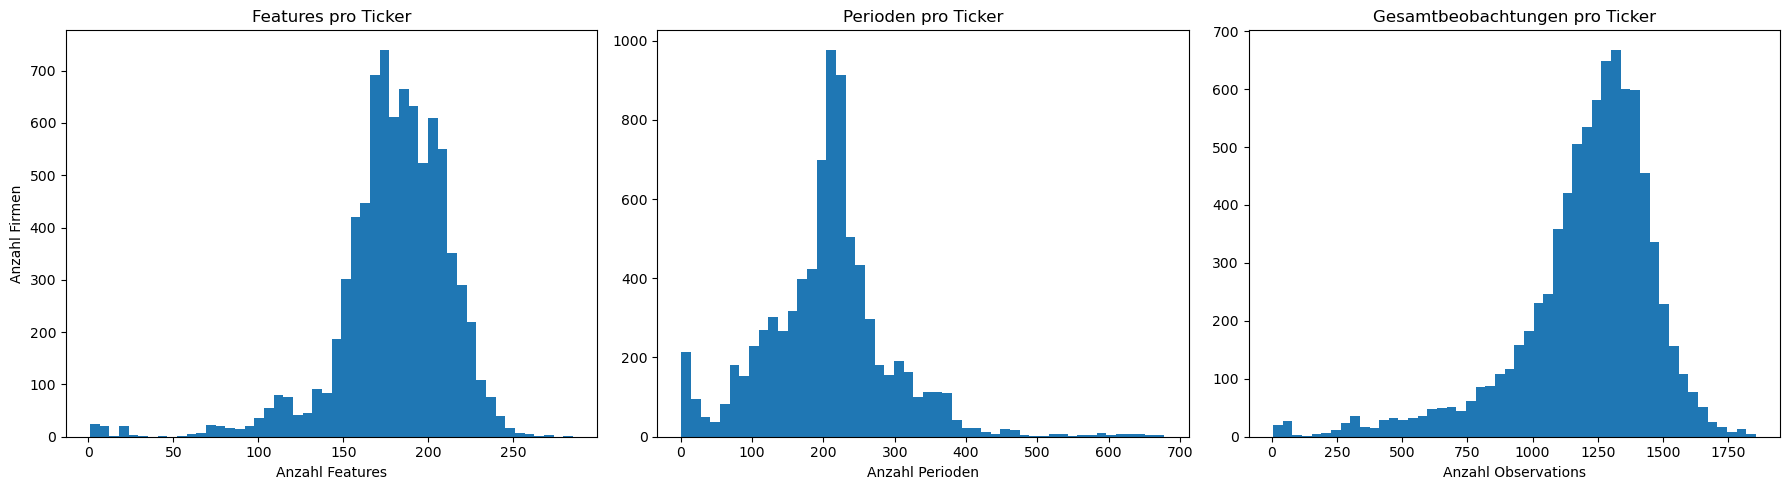

9877572
8852986
7016


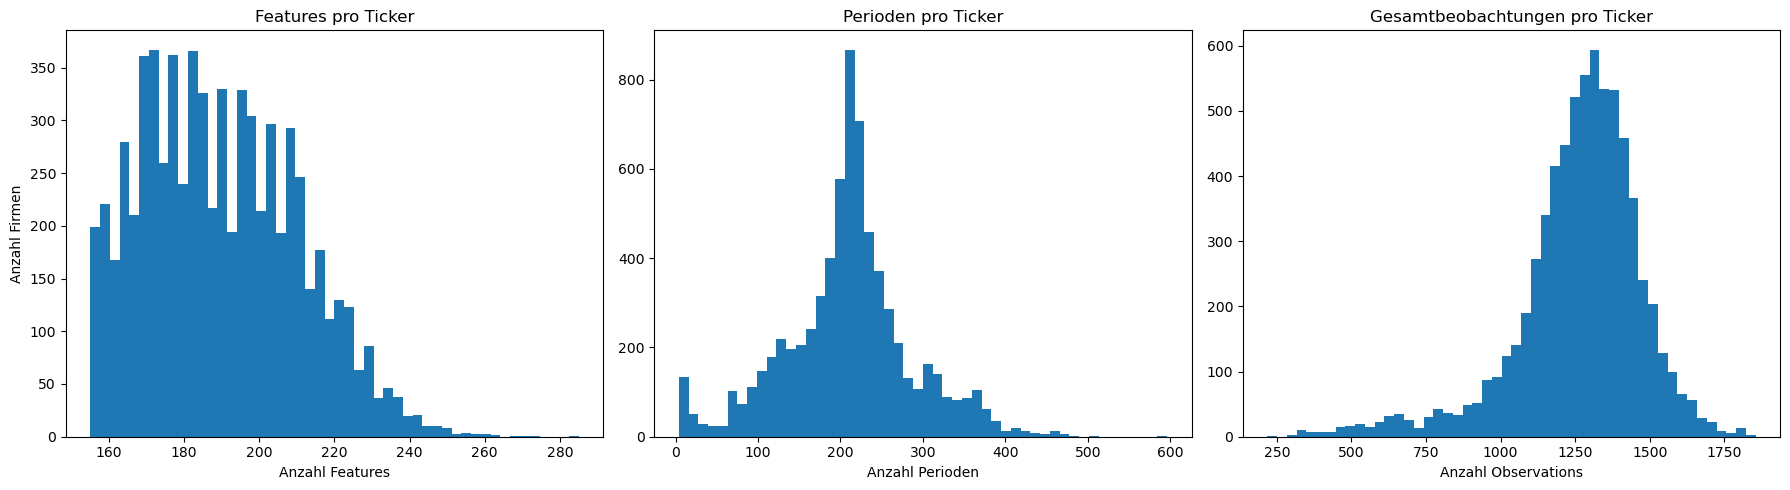

In [11]:
analyzer = YahooFinanceCoverageAnalyzer()

df_filtered = analyzer.filter_by_quantile(df, 0.15)
analyzer.plot_coverage_distributions(df)
print(len(df))
print(len(df_filtered))
analyzer.plot_coverage_distributions(df_filtered)

In [44]:
from pathlib import Path
import duckdb
import pandas as pd


class CurrencyHarmonizer:
    def __init__(self, db_name="bronze_company.db"):
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data" / db_name
        self.con = duckdb.connect(str(db_path))

    def close(self):
        self.con.close()

    def load_bronze_financials(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT
                ticker,
                date,
                affiliation,
                item_description,
                value,
                unit
            FROM bronze_financials
        """).df()

    def load_fx_rates(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT
                base_currency,
                quote_currency,
                date,
                rate
            FROM bronze_fx_rates
        """).df()
    def harmonize_to_usd(self) -> pd.DataFrame:
        """
        Harmonisiert Werte aus bronze_financials nach USD.

        Regeln:
        - unit == 'USD' -> USD_Value = value
        - unit in ('percent', 'shares') -> USD_Value = value
        - sonst -> USD_Value = value * FX-Rate
        - falls für den Tag kein FX-Match existiert:
        verwende die letzte verfügbare Rate derselben Währung

        Zusätzlich:
        - neue Spalte 'HarmonizedUnit'
        - 'USD' bei umgerechneten Werten
        - ursprüngliche Unit bei percent/shares/USD etc.
        """

        financials = self.load_bronze_financials().copy()
        fx = self.load_fx_rates().copy()

        if financials.empty:
            return pd.DataFrame(columns=[
                "ticker", "date", "affiliation", "item_description",
                "value", "unit", "USD_Value", "HarmonizedUnit"
            ])

        # -----------------------------
        # Typen bereinigen
        # -----------------------------
        financials["date"] = pd.to_datetime(financials["date"], errors="coerce")
        financials["value"] = pd.to_numeric(financials["value"], errors="coerce")
        financials["unit"] = financials["unit"].astype(str).str.strip()
        financials["unit_clean"] = financials["unit"].str.upper()

        fx["date"] = pd.to_datetime(fx["date"], errors="coerce")
        fx["base_currency"] = fx["base_currency"].astype(str).str.strip().str.upper()
        fx["quote_currency"] = fx["quote_currency"].astype(str).str.strip().str.upper()
        fx["rate"] = pd.to_numeric(fx["rate"], errors="coerce")

        # Nur gültige FX-Raten nach USD
        fx = fx[fx["quote_currency"] == "USD"].copy()
        fx = fx.dropna(subset=["base_currency", "date", "rate"])
        fx = fx.sort_values(["base_currency", "date"])
        fx = fx.drop_duplicates(subset=["base_currency", "date"], keep="last")

        # Sonderfälle ohne Umrechnung
        passthrough_mask = financials["unit_clean"].isin(["USD", "PERCENT", "SHARES"])
        passthrough_df = financials[passthrough_mask].copy()
        fx_needed_df = financials[~passthrough_mask].copy()

        passthrough_df["USD_Value"] = passthrough_df["value"]
        passthrough_df["HarmonizedUnit"] = passthrough_df["unit"]

        # -----------------------------
        # FX-Umrechnung pro Währung
        # -----------------------------
        converted_parts = []

        for currency, group in fx_needed_df.groupby("unit_clean", dropna=False):
            group = group.copy()

            fx_group = fx[fx["base_currency"] == currency].copy()

            group = group.sort_values("date")
            fx_group = fx_group.sort_values("date")

            if fx_group.empty:
                group["rate"] = pd.NA
                group["USD_Value"] = pd.NA
                group["HarmonizedUnit"] = pd.NA
            else:
                merged = pd.merge_asof(
                    group,
                    fx_group[["date", "rate"]],
                    on="date",
                    direction="backward"
                )
                merged["USD_Value"] = merged["value"] * merged["rate"]
                merged["HarmonizedUnit"] = "USD"
                group = merged

            converted_parts.append(group)

        if converted_parts:
            converted_df = pd.concat(converted_parts, ignore_index=True)
        else:
            converted_df = pd.DataFrame(
                columns=list(fx_needed_df.columns) + ["rate", "USD_Value", "HarmonizedUnit"]
            )

        # -----------------------------
        # Alles zusammenführen
        # -----------------------------
        result = pd.concat([passthrough_df, converted_df], ignore_index=True)

        result = result[
            [
                "ticker", "date", "affiliation", "item_description",
                "value", "unit", "USD_Value", "HarmonizedUnit"
            ]
        ].copy()

        result = result.sort_values(
            ["ticker", "date", "affiliation", "item_description"]
        ).reset_index(drop=True)

        return result
    '''
    def harmonize_to_usd(self) -> pd.DataFrame:
        """
        Harmonisiert Werte aus bronze_financials nach USD.

        Regeln:
        - unit == 'USD' -> USD_Value = value
        - unit in ('percent', 'shares') -> USD_Value = value
        - sonst -> USD_Value = value * FX-Rate
        - falls für den Tag kein FX-Match existiert:
          verwende die letzte verfügbare Rate derselben Währung
        """

        financials = self.load_bronze_financials().copy()
        fx = self.load_fx_rates().copy()

        if financials.empty:
            return pd.DataFrame(columns=[
                "ticker", "date", "affiliation", "item_description",
                "value", "unit", "USD_Value"
            ])

        # -----------------------------
        # Typen bereinigen
        # -----------------------------
        financials["date"] = pd.to_datetime(financials["date"], errors="coerce")
        financials["value"] = pd.to_numeric(financials["value"], errors="coerce")
        financials["unit"] = financials["unit"].astype(str).str.strip()
        financials["unit_clean"] = financials["unit"].str.upper()

        fx["date"] = pd.to_datetime(fx["date"], errors="coerce")
        fx["base_currency"] = fx["base_currency"].astype(str).str.strip().str.upper()
        fx["quote_currency"] = fx["quote_currency"].astype(str).str.strip().str.upper()
        fx["rate"] = pd.to_numeric(fx["rate"], errors="coerce")

        # Nur gültige FX-Raten nach USD
        fx = fx[fx["quote_currency"] == "USD"].copy()
        fx = fx.dropna(subset=["base_currency", "date", "rate"])
        fx = fx.sort_values(["base_currency", "date"])
        fx = fx.drop_duplicates(subset=["base_currency", "date"], keep="last")

        # Sonderfälle ohne Umrechnung
        passthrough_mask = financials["unit_clean"].isin(["USD", "PERCENT", "SHARES"])
        passthrough_df = financials[passthrough_mask].copy()
        fx_needed_df = financials[~passthrough_mask].copy()

        passthrough_df["USD_Value"] = passthrough_df["value"]

        # -----------------------------
        # FX-Umrechnung pro Währung
        # -----------------------------
        converted_parts = []

        for currency, group in fx_needed_df.groupby("unit_clean", dropna=False):
            group = group.copy()

            fx_group = fx[fx["base_currency"] == currency].copy()

            group = group.sort_values("date")
            fx_group = fx_group.sort_values("date")

            if fx_group.empty:
                group["rate"] = pd.NA
                group["USD_Value"] = pd.NA
            else:
                merged = pd.merge_asof(
                    group,
                    fx_group[["date", "rate"]],
                    on="date",
                    direction="backward"
                )
                merged["USD_Value"] = merged["value"] * merged["rate"]
                group = merged

            converted_parts.append(group)

        if converted_parts:
            converted_df = pd.concat(converted_parts, ignore_index=True)
        else:
            converted_df = pd.DataFrame(columns=list(fx_needed_df.columns) + ["rate", "USD_Value"])

        # -----------------------------
        # Alles zusammenführen
        # -----------------------------
        result = pd.concat([passthrough_df, converted_df], ignore_index=True)

        result = result[
            ["ticker", "date", "affiliation", "item_description", "value", "unit", "USD_Value"]
        ].copy()

        result = result.sort_values(
            ["ticker", "date", "affiliation", "item_description"]
        ).reset_index(drop=True)

        return result
    '''
    def create_silver_table(self):
        self.con.execute("""
            CREATE TABLE IF NOT EXISTS silver_financials_usd (
                ticker VARCHAR,
                date DATE,
                affiliation VARCHAR,
                item_description VARCHAR,
                value DOUBLE,
                unit VARCHAR,
                USD_Value DOUBLE
            );
        """)

    def write_silver_table(self, replace: bool = True):
        df = self.harmonize_to_usd()
        self.create_silver_table()

        if replace:
            self.con.execute("DELETE FROM silver_financials_usd")

        if df.empty:
            return

        self.con.register("harmonized_df", df)
        self.con.execute("""
            INSERT INTO silver_financials_usd
            SELECT * FROM harmonized_df
        """)
        self.con.unregister("harmonized_df")

    def get_silver_financials_usd(self) -> pd.DataFrame:
        self.create_silver_table()
        return self.con.execute("""
            SELECT *
            FROM silver_financials_usd
            ORDER BY ticker, date, item_description
        """).df()

    def run(self, replace: bool = True):
        self.write_silver_table(replace=replace)

In [45]:
harmonizer = CurrencyHarmonizer()
# Nur DataFrame erzeugen
df_usd = harmonizer.harmonize_to_usd()
harmonizer.close()

In [46]:
df_usd

,ticker,date,affiliation,item_description,value,unit,USD_Value,HarmonizedUnit
0,0001.HK,2000-05-16,dividends,dividends,1.050000e+00,HKD,NaN,USD
1,0001.HK,2000-10-10,dividends,dividends,3.800000e-01,HKD,NaN,USD
2,0001.HK,2001-05-15,dividends,dividends,1.220000e+00,HKD,NaN,USD
3,0001.HK,2001-10-09,dividends,dividends,3.800000e-01,HKD,NaN,USD
4,0001.HK,2002-05-14,dividends,dividends,1.220000e+00,HKD,NaN,USD
...,...,...,...,...,...,...,...,...
9877567,ZYME,2026-06-01,price_history,Volume,4.997960e+06,shares,4.997960e+06,shares
9877568,ZYME,2026-06-08,major_holders,insidersPercentHeld,1.272000e-02,percent,1.272000e-02,percent
9877569,ZYME,2026-06-08,major_holders,institutionsCount,3.030000e+02,percent,3.030000e+02,percent
9877570,ZYME,2026-06-08,major_holders,institutionsFloatPercentHeld,1.002570e+00,percent,1.002570e+00,percent


In [47]:
class SilverMapping():
    def __init__(self):
        self.commodity = pd.read_csv("commodity.csv")
        self.interest = pd.read_csv("interest.csv")
        self.gmd = pd.read_csv("gmd.csv")
    #Entity filtering
    def yahoo_holder_entities(self, df):
        holders = df[df['affiliation'].isin(["mutualfund_holders", "institutional_holders"])]
        entities = (
            holders[["item_description", "affiliation"]]
            .drop_duplicates(subset=['item_description'])
            .sort_values("item_description")
            .reset_index(drop=True)
            .copy()
        )
        entity_type_map = {
        "mutualfund_holders": "MutualFund",
        "institutional_holders": "InstitutionalHolder"
    }
        entities['EntityCode'] = entities['item_description']
        entities['EntityType'] = entities['affiliation'].map(entity_type_map)
        entities = entities.rename(columns={'item_description': "EntityName"})
        return entities[["EntityName", "EntityCode", "EntityType"]]
    def yahoo_entities(self, df):
        
        entities = (
            df[["ticker"]]
            .drop_duplicates()
            .sort_values("ticker")
            .reset_index(drop=True)
            .copy()
        )
        entities["EntityName"] = "To be added"
        entities["EntityType"] = "Company"
        entities["EntityCode"] = entities["ticker"]
        return entities[["EntityName","EntityCode" ,"EntityType"]]
    def gmd_entities(self, df):
        entities = (
            df[["iso3", "countryname"]]
            .dropna(subset=["iso3"])
            .drop_duplicates(subset=["iso3"])
            .sort_values("iso3")
            .reset_index(drop=True)
            .copy()
        )
        entities["EntityName"] = entities["countryname"]
        entities["EntityType"] = "State"
        entities["EntityCode"] = entities["iso3"]
        return entities[["EntityName", "EntityCode" ,"EntityType"]]
    def imf_commodity_entities(self, df):
        entities = (
            df[["indicator", "commodity_name"]]
            .dropna(subset=["indicator"])
            .drop_duplicates(subset=["indicator"])
            .sort_values("indicator")
            .reset_index(drop=True)
            .copy()
        )
        entities["EntityName"] = entities["commodity_name"]
        entities["EntityType"] = "Commodity"
        entities["EntityCode"] = entities["indicator"]
        return entities[["EntityName", "EntityCode" ,"EntityType"]]
    def fx_entities(self, df):
        entities = (
            df[["base_currency", "quote_currency"]]
            .dropna(subset=["base_currency"])
            .drop_duplicates(subset=["base_currency"])
            .sort_values("base_currency")
            .reset_index(drop=True)
            .copy()
        )
        entities["EntityName"] = entities["base_currency"] + "_to_" + entities["quote_currency"]
        entities["EntityType"] = "Currency"
        entities["EntityCode"] = entities["base_currency"]
        return entities[["EntityName", "EntityCode" ,"EntityType"]]
    def wikidata_entities(self, df):
        df = df.copy()
        # relevante Relationen
        df = df[df['item_description'].isin(['products', 'instance_of', 'part_of'])]
        # Mapping Relation → EntityType
        entity_type_map = {
            "products": "Product",
            "instance_of": "Class",
            "part_of": "Group"
        }
        # EntityType setzen (bevor Spalten reduziert werden!)
        df['EntityType'] = df['item_description'].map(entity_type_map)

        # Duplikate auf Entity-Ebene entfernen (NICHT unique() so!)
        df = df.drop_duplicates(subset=['value'])

        # finale Spalten auswählen
        df = df[['value', 'label', 'EntityType']].rename(columns={
            "value": "EntityCode",
            "label": "EntityName"
        })
        return df
    #Item filtering
    def financial_items(self, df):
        df = df[~df['affiliation'].isin(["mutualfund_holders", "institutional_holders"])]
        # 1. Count je Item
        item_counts = (df.groupby("item_description").size().reset_index(name="ItemCount"))
        # 2. Items bauen (wie bisher)
        items = (
            df[["item_description", "affiliation", "unit"]]
            .dropna(subset=["item_description"])
            .drop_duplicates(subset=["item_description"])
            .sort_values("item_description")
            .reset_index(drop=True)
            .copy()
        )
        # 3. Join mit Counts
        items = items.merge(item_counts, on="item_description", how="left")
        # 4. Spalten bauen
        items["ItemName"] = items["item_description"]
        items["ItemCategory"] = items["affiliation"]
        items["ItemUnit"] = items["unit"]
        items["ItemSource"] = "YahooFinance"
        items["Item_to_Entity"] = "Company"
        return items[["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "ItemCount", "Item_to_Entity"]]
    def gmd_items(self, df):
        item_counts = (df.groupby("item_description").size().reset_index(name="ItemCount"))
        items = (
            df[["item_description", "affiliation", "unit"]]
            .dropna(subset=["item_description"])
            .drop_duplicates(subset=["item_description"])
            .sort_values("item_description")
            .reset_index(drop=True)
            .copy()
        )
        items = items.merge(item_counts, on="item_description", how="left")
        items["ItemName"] = items["item_description"]
        items["ItemCategory"] = items["affiliation"]
        items["ItemUnit"] = items["unit"]
        items["ItemSource"] = "GlobalMacroData"
        items["Item_to_Entity"] = "State"
        return items[["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "ItemCount", "Item_to_Entity"]]
    def commodity_items(self, df):
        item_counts = (df.groupby("commodity_name").size().reset_index(name="ItemCount"))
        items = (
            df[["commodity_name", "affiliation", "unit"]]
            .dropna(subset=["commodity_name"])
            .drop_duplicates(subset=["commodity_name"])
            .sort_values("commodity_name")
            .reset_index(drop=True)
            .copy()
        )
        items = items.merge(item_counts, on="commodity_name", how="left")
        items["ItemName"] = items["commodity_name"]
        items["ItemCategory"] = items["affiliation"]
        items["ItemUnit"] = items["unit"]
        items["ItemSource"] = "InternationalMonetaryFund"
        items["Item_to_Entity"] = "Commodity"
        return items[["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "ItemCount", "Item_to_Entity"]]
    def interest_items(self, df):
        item_counts = (df.groupby("interest_name").size().reset_index(name="ItemCount"))
        items = (
            df[["interest_name", "affiliation", "unit"]]
            .dropna(subset=["interest_name"])
            .drop_duplicates(subset=["interest_name"])
            .sort_values("interest_name")
            .reset_index(drop=True)
            .copy()
        )
        items = items.merge(item_counts, on="interest_name", how="left")
        items["ItemName"] = items["interest_name"]
        items["ItemCategory"] = items["affiliation"]
        items["ItemUnit"] = items["unit"]
        items["ItemSource"] = "InternationalMonetaryFund"
        items["Item_to_Entity"] = "State"
        return items[["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "ItemCount", "Item_to_Entity"]]
    def currency_items(self, df):
        item_counts = (df.groupby("base_currency").size().reset_index(name="ItemCount"))
        items = (
            df[["base_currency", "quote_currency"]]
            .dropna(subset=["base_currency"])
            .drop_duplicates(subset=["base_currency"])
            .sort_values("base_currency")
            .reset_index(drop=True)
            .copy()
        )
        items = items.merge(item_counts, on="base_currency", how="left")
        items["ItemName"] = items["base_currency"]
        items["ItemCategory"] = 'Currency_to_USD'
        items["ItemUnit"] = 'ExchangeRate'
        items["ItemSource"] = "YahooFinance"
        items["Item_to_Entity"] = "Currency"
        return items[["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "ItemCount", "Item_to_Entity"]]
    #Relation Filtering
    def add_relation_metadata(self, df):
        if "item_description" not in df.columns:
            raise ValueError("Das DataFrame muss eine Spalte 'item_description' enthalten.")
        out = df.copy()
        relation_map = {
            "instance_of": {
                "source_type": "company",
                "target_type": "class",
                "relation_schema": "company->class",
                "is_directed": True,
                "relation_family": "ontology",
                "data_source": "wikidata",
            },
            "products": {
                "source_type": "company",
                "target_type": "product",
                "relation_schema": "company->product",
                "is_directed": True,
                "relation_family": "product_relation",
                "data_source": "wikidata",
            },
            "part_of": {
                "source_type": "company",
                "target_type": "group",
                "relation_schema": "company->group",
                "is_directed": True,
                "relation_family": "membership",
                "data_source": "wikidata",
            },
            "owned_by": {
                "source_type": "company",
                "target_type": "company",
                "relation_schema": "company->company",
                "is_directed": True,
                "relation_family": "ownership",
                "data_source": "wikidata",
            },
            "subsidiaries": {
                "source_type": "company",
                "target_type": "company",
                "relation_schema": "company->company",
                "is_directed": True,
                "relation_family": "ownership",
                "data_source": "wikidata",
            },
            "investments": {
                "source_type": "company",
                "target_type": "company",
                "relation_schema": "company->company",
                "is_directed": True,
                "relation_family": "financial_exposure",
                "data_source": "wikidata",
            },
        }

        meta_cols = [
            "source_type",
            "target_type",
            "relation_schema",
            "is_directed",
            "relation_family",
            "data_source",
        ]

        # Standardmäßig leere Spalten anlegen
        for col in meta_cols:
            out[col] = pd.NA

        # item_type und data_source kannst du für alle bekannten/erwarteten Relationen
        # auch pauschal setzen, hier aber bewusst nur über das Mapping
        mapped = out["item_description"].map(relation_map)

        for col in meta_cols:
            out[col] = mapped.map(
                lambda x: x.get(col) if isinstance(x, dict) else pd.NA
            )
        realtion_counts = (out.groupby("item_description").size().reset_index(name="RelationCount"))
        out = (
            out[["item_description", "source_type",	"target_type",	"relation_schema",	"is_directed",	"relation_family",	"data_source"]]
            .dropna(subset=["item_description"])
            .drop_duplicates(subset=["item_description"])
            .sort_values("item_description")
            .reset_index(drop=True)
            .copy()
        )
        out = out.merge(realtion_counts, on="item_description", how="left")
        out["unit"] = pd.NA
        return out
    def yf_relations(self, df):
        holders = df[df["affiliation"].isin(["mutualfund_holders", "institutional_holders"])].copy()
        relation_counts = (
            holders.groupby("affiliation")
            .size()
            .reset_index(name="RelationCount")
        )
        relation_map = {
            "mutualfund_holders": {
                "source_type": "company",
                "target_type": "Fund",
                "relation_schema": "company->Fund",
                "is_directed": True,
                "relation_family": "ownership",
                "data_source": "YahooFinance",
                "unit": "percent",
            },
            "institutional_holders": {
                "source_type": "company",
                "target_type": "institution",
                "relation_schema": "company->institution",
                "is_directed": True,
                "relation_family": "ownership",
                "data_source": "YahooFinance",
                "unit": "percent",
            },
        }
        out = (
            holders[["affiliation"]]
            .drop_duplicates()
            .rename(columns={"affiliation": "item_description"})
            .reset_index(drop=True)
        )
        meta_cols = [
            "source_type",
            "target_type",
            "relation_schema",
            "is_directed",
            "relation_family",
            "data_source",
            "unit",
        ]
        mapped = out["item_description"].map(relation_map)
        for col in meta_cols:
            out[col] = mapped.map(lambda x: x.get(col) if isinstance(x, dict) else pd.NA)

        out = out.merge(
            relation_counts.rename(columns={"affiliation": "item_description"}),
            on="item_description",
            how="left"
        )

        out = out[
            [
                "item_description",
                "source_type",
                "target_type",
                "relation_schema",
                "is_directed",
                "relation_family",
                "data_source",
                "RelationCount",
                "unit",
            ]
        ]

        return out
    #Relationobservations
    def wikidata_observations(self, df):
        df = df[["ticker", "item_description", "value", "label"]].rename(columns={"ticker": "source_ticker", "value": "destination"})
        df["unit"] = pd.NA
        df["value"] = pd.NA
        return df
    def yf_relation_observations(self, df):
        holders = df[df["affiliation"].isin(["mutualfund_holders", "institutional_holders"])].copy()
        holders = holders[["ticker", "affiliation", "item_description", "value", "unit"]].rename(columns={"ticker": "source_ticker", "item_description": "destination", "affiliation": "item_description"})
        holders["label"] = pd.NA
        return holders
    #Observations
    def yf_observations(self, df):
        df = df[~df['affiliation'].isin(["mutualfund_holders", "institutional_holders"])]
        df = df[['ticker', 'item_description', 'date', 'USD_Value', 'HarmonizedUnit']].rename(columns={'ticker': 'entity', 'item_description': 'item', 'USD_Value': 'value', 'HarmonizedUnit': 'unit'})
        df['EntityType'] = 'Company'
        return df
    def gmd_observations(self, df):
        df = df[['iso3', 'item_description', 'year',  'value', 'unit']].rename(columns={'iso3': 'entity', 'year': 'date', 'item_description': 'item'})
        df['EntityType'] = 'State'
        return df
    def interest_observations(self,df):
        df = df[['iso3', 'interest_name', 'date', 'value', 'unit']].rename(columns={'iso3': 'entity', 'interest_name': 'item'})
        df['EntityType'] = 'State'
        return df
    def commodity_observations(self, df):
        df = df[['indicator', 'commodity_name', 'date', 'value', 'unit']].rename(columns={'indicator': 'entity', 'commodity_name': 'item'})
        df['EntityType'] = 'Commodity'
        return df
    def fx_observations(self, df):
        df['item'] = df['base_currency']
        df['unit'] = 'ExchangeRate'
        df = df[['base_currency', 'item', 'date', 'rate', 'unit']].rename(columns={'base_currency': 'entity', 'rate': 'value'})
        df['EntityType'] = 'Currency'
        return df
    

In [48]:
df_usd

,ticker,date,affiliation,item_description,value,unit,USD_Value,HarmonizedUnit
0,0001.HK,2000-05-16,dividends,dividends,1.050000e+00,HKD,NaN,USD
1,0001.HK,2000-10-10,dividends,dividends,3.800000e-01,HKD,NaN,USD
2,0001.HK,2001-05-15,dividends,dividends,1.220000e+00,HKD,NaN,USD
3,0001.HK,2001-10-09,dividends,dividends,3.800000e-01,HKD,NaN,USD
4,0001.HK,2002-05-14,dividends,dividends,1.220000e+00,HKD,NaN,USD
...,...,...,...,...,...,...,...,...
9877567,ZYME,2026-06-01,price_history,Volume,4.997960e+06,shares,4.997960e+06,shares
9877568,ZYME,2026-06-08,major_holders,insidersPercentHeld,1.272000e-02,percent,1.272000e-02,percent
9877569,ZYME,2026-06-08,major_holders,institutionsCount,3.030000e+02,percent,3.030000e+02,percent
9877570,ZYME,2026-06-08,major_holders,institutionsFloatPercentHeld,1.002570e+00,percent,1.002570e+00,percent


In [49]:
mapper = SilverMapping()
reader = DataHubReader()
#Entities
yf_entities = mapper.yahoo_entities(df_usd)
yf_holder_entities = mapper.yahoo_holder_entities(df_usd)
fx = reader.get_fx_rates()
fx_entities = mapper.fx_entities(fx)

#gmd_entities = mapper.gmd_entities(gmd_after)
#commodity = pd.read_csv("commodity.csv")
#commodity_entities = mapper.imf_commodity_entities(commodity)
#entities = pd.concat([yf_entities, fx_entities, gmd_entities, commodity_entities])
#wikidata = pd.read_csv("wikidata.csv")
#wikidata_entities = mapper.wikidata_entities(wikidata)
#Items
yf_items = mapper.financial_items(df_usd)
#gmd_items = mapper.gmd_items(gmd_after)
#commodity = pd.read_csv("commodity.csv")
#commodity_items = mapper.commodity_items(commodity)
#interest = pd.read_csv("interest.csv")
#interest_items = mapper.interest_items(interest)
#currency_items = mapper.currency_items(fx)
#items = pd.concat([yf_items, gmd_items, commodity_items, interest_items, currency_items])
#Realtionen
#wikidata_relations = mapper.add_relation_metadata(wikidata)
yf_realtions = mapper.yf_relations(df_usd)
#RelationObservations
#wikidata_realtion_obs = mapper.wikidata_observations(wikidata)
yf_relation_obs = mapper.yf_relation_observations(df_usd)
#Observations
yf_obs = mapper.yf_observations(df_usd)
#gmd_obs = mapper.gmd_observations(gmd_after)
#fx_obs = mapper.fx_observations(fx)
#commodity_obs = mapper.commodity_observations(commodity)
#interest_obs = mapper.interest_observations(interest)

In [50]:
yf_entities

,EntityName,EntityCode,EntityType
0,To be added,0001.HK,Company
1,To be added,0002.HK,Company
2,To be added,0003.HK,Company
3,To be added,0004.HK,Company
4,To be added,0005.HK,Company
...,...,...,...
8187,To be added,ZV.MI,Company
8188,To be added,ZVIA,Company
8189,To be added,ZVRA,Company
8190,To be added,ZWS,Company


In [51]:
yf_holder_entities

,EntityName,EntityCode,EntityType
0,&Partners LLC,&Partners LLC,InstitutionalHolder
1,-AB Emerging Markets Opportunities ETF,-AB Emerging Markets Opportunities ETF,MutualFund
2,-AB International Growth Portfolio,-AB International Growth Portfolio,InstitutionalHolder
3,-Acuitas Small Cap Active ETF,-Acuitas Small Cap Active ETF,MutualFund
4,-American Century Federated Managed Volatility...,-American Century Federated Managed Volatility...,MutualFund
...,...,...,...
4990,"iShares, Inc.-iShares MSCI Hong Kong ETF","iShares, Inc.-iShares MSCI Hong Kong ETF",MutualFund
4991,"iShares, Inc.-iShares MSCI Netherlands ETF","iShares, Inc.-iShares MSCI Netherlands ETF",InstitutionalHolder
4992,"iShares, Inc.-iShares MSCI South Africa ETF","iShares, Inc.-iShares MSCI South Africa ETF",InstitutionalHolder
4993,"iShares, Inc.-iShares MSCI Spain ETF","iShares, Inc.-iShares MSCI Spain ETF",MutualFund


In [52]:
df_usd

,ticker,date,affiliation,item_description,value,unit,USD_Value,HarmonizedUnit
0,0001.HK,2000-05-16,dividends,dividends,1.050000e+00,HKD,NaN,USD
1,0001.HK,2000-10-10,dividends,dividends,3.800000e-01,HKD,NaN,USD
2,0001.HK,2001-05-15,dividends,dividends,1.220000e+00,HKD,NaN,USD
3,0001.HK,2001-10-09,dividends,dividends,3.800000e-01,HKD,NaN,USD
4,0001.HK,2002-05-14,dividends,dividends,1.220000e+00,HKD,NaN,USD
...,...,...,...,...,...,...,...,...
9877567,ZYME,2026-06-01,price_history,Volume,4.997960e+06,shares,4.997960e+06,shares
9877568,ZYME,2026-06-08,major_holders,insidersPercentHeld,1.272000e-02,percent,1.272000e-02,percent
9877569,ZYME,2026-06-08,major_holders,institutionsCount,3.030000e+02,percent,3.030000e+02,percent
9877570,ZYME,2026-06-08,major_holders,institutionsFloatPercentHeld,1.002570e+00,percent,1.002570e+00,percent


In [53]:
yf_items

,ItemName,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
0,AccountsPayable,balance_sheet,HKD,YahooFinance,36300,Company
1,AccountsReceivable,balance_sheet,HKD,YahooFinance,34115,Company
2,AccruedInterestReceivable,balance_sheet,CNY,YahooFinance,983,Company
3,AccumulatedDepreciation,balance_sheet,HKD,YahooFinance,34449,Company
4,AdditionalPaidInCapital,balance_sheet,HKD,YahooFinance,33239,Company
...,...,...,...,...,...,...
354,insidersPercentHeld,major_holders,percent,YahooFinance,8056,Company
355,institutionsCount,major_holders,percent,YahooFinance,8056,Company
356,institutionsFloatPercentHeld,major_holders,percent,YahooFinance,8051,Company
357,institutionsPercentHeld,major_holders,percent,YahooFinance,8051,Company


In [54]:
yf_relation_obs

,source_ticker,item_description,destination,value,unit,label
1307,0001.HK,mutualfund_holders,-Price (T.Rowe) International Value Equity Trust,0.0031,percent,NaN
1308,0001.HK,mutualfund_holders,VANGUARD TAX-MANAGED FUNDS-Vanguard Developed ...,0.0066,percent,NaN
1314,0001.HK,mutualfund_holders,HARTFORD MUTUAL FUNDS INC/CT-The Hartford Inte...,0.0024,percent,NaN
1315,0001.HK,mutualfund_holders,"T. ROWE PRICE Intl Fd.S, INC.-T. Rowe Price In...",0.0023,percent,NaN
1316,0001.HK,mutualfund_holders,VANGUARD STAR FUNDS-Vanguard Total Internation...,0.0102,percent,NaN
...,...,...,...,...,...,...
9877547,ZYME,institutional_holders,Vanguard Capital Management LLC,0.0271,percent,NaN
9877548,ZYME,mutualfund_holders,VANGUARD INDEX FUNDS-Vanguard Total Stock Mark...,0.0262,percent,NaN
9877554,ZYME,mutualfund_holders,iShares Trust-iShares Biotechnology ETF,0.0084,percent,NaN
9877555,ZYME,mutualfund_holders,iShares Trust-iShares Russell 2000 ETF,0.0187,percent,NaN


In [93]:
wikidata_realtion_obs

,source_ticker,item_description,destination,label,unit,value
0,ALATA.PA,products,Q5060160,Centipede: Infestation,NaN,NaN
1,ALCOX.PA,products,Q3335996,naproxcinod,NaN,NaN
2,ALPUL.PA,products,Q1804779,Farming Simulator,NaN,NaN
3,ALPUL.PA,products,Q22019750,Vampyr,NaN,NaN
4,ALPUL.PA,products,Q29257518,The Surge,NaN,NaN
...,...,...,...,...,...,...
8166,UCG.MI,part_of,Q981010,EURO STOXX 50,NaN,NaN
8167,TIT.MI,owned_by,PST.MI,Poste Italiane,NaN,NaN
8168,TITR.MI,owned_by,PST.MI,Poste Italiane,NaN,NaN
8169,SGF.MI,owned_by,CIR.MI,CIR Group,NaN,NaN


In [20]:
entities = pd.concat([yf_entities, fx_entities, gmd_entities, commodity_entities, yf_holder_entities, wikidata_entities])
items = pd.concat([yf_items, gmd_items, commodity_items, interest_items, currency_items])
relationen = pd.concat([wikidata_relations, yf_realtions])
relations_obs = pd.concat([wikidata_realtion_obs, yf_relation_obs])
observations = pd.concat([yf_obs, gmd_obs, fx_obs, commodity_obs, interest_obs])
relationen

,item_description,source_type,target_type,relation_schema,is_directed,relation_family,data_source,RelationCount,unit
0,instance_of,company,class,company->class,True,ontology,wikidata,5482,NaN
1,investments,company,company,company->company,True,financial_exposure,wikidata,53,NaN
2,owned_by,company,company,company->company,True,ownership,wikidata,222,NaN
3,part_of,company,group,company->group,True,membership,wikidata,880,NaN
4,products,company,product,company->product,True,product_relation,wikidata,1453,NaN
5,subsidiaries,company,company,company->company,True,ownership,wikidata,58,NaN
0,institutional_holders,company,institution,company->institution,True,ownership,YahooFinance,42291,percent
1,mutualfund_holders,company,Fund,company->Fund,True,ownership,YahooFinance,38661,percent


In [103]:
relations_obs

,source_ticker,item_description,destination,label,unit,value
0,ALATA.PA,products,Q5060160,Centipede: Infestation,NaN,NaN
1,ALCOX.PA,products,Q3335996,naproxcinod,NaN,NaN
2,ALPUL.PA,products,Q1804779,Farming Simulator,NaN,NaN
3,ALPUL.PA,products,Q22019750,Vampyr,NaN,NaN
4,ALPUL.PA,products,Q29257518,The Surge,NaN,NaN
...,...,...,...,...,...,...
7072424,ZYME,mutualfund_holders,Fidelity Securities Fund-Fidelity Small Cap Gr...,NaN,percent,0.0059
7072425,ZYME,mutualfund_holders,VANGUARD INDEX FUNDS-Vanguard Total Stock Mark...,NaN,percent,0.0262
7072426,ZYME,mutualfund_holders,iShares Trust-iShares Biotechnology ETF,NaN,percent,0.0085
7072427,ZYME,mutualfund_holders,iShares Trust-iShares Russell 2000 ETF,NaN,percent,0.0201


In [55]:
entities

NameError: name 'entities' is not defined

In [132]:
items[items['Item_to_Entity'] == "State"]

,ItemName,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
0,BankingCrisis,crisis,Rating,GlobalMacroData,5735,State
1,CA_GDP,external_sector,Percent,GlobalMacroData,5735,State
2,CA_USD,external_sector,USD,GlobalMacroData,5735,State
3,CPI,prices,Index,GlobalMacroData,5735,State
4,CurrencyCrisis,crisis,Rating,GlobalMacroData,5735,State
...,...,...,...,...,...,...
36,Refinancing Rate,policy_rates,Percent per annum,InternationalMonetaryFund,109,State
37,Repurchase agreement Rate,market_rates,Percent per annum,InternationalMonetaryFund,229,State
38,Reverse repurchase agreement Rate,market_rates,Percent per annum,InternationalMonetaryFund,212,State
39,Savings Rate,deposit_rates,Percent per annum,InternationalMonetaryFund,2671,State


In [36]:
observations

,entity,item,date,value,unit
0,2020.OL,dividends,2019-11-11 00:00:00,NaN,USD
1,2020.OL,dividends,2019-12-06 00:00:00,NaN,USD
2,2020.OL,dividends,2020-01-14 00:00:00,NaN,USD
3,2020.OL,dividends,2020-02-13 00:00:00,NaN,USD
4,2020.OL,dividends,2020-08-17 00:00:00,NaN,USD
...,...,...,...,...,...
43204,ZWE,Lending Rate,2025-08-01,46.330,Percent per annum
43205,ZWE,Lending Rate,2025-09-01,46.220,Percent per annum
43206,ZWE,Lending Rate,2025-10-01,46.400,Percent per annum
43207,ZWE,Lending Rate,2025-11-01,46.750,Percent per annum


In [56]:
from __future__ import annotations
from pathlib import Path
import duckdb
import pandas as pd

#Mit Relationen 
class SilverDataHub_:
    def __init__(self, db_path: str = r"C:\Diversification\data\silver_company.db") -> None:
        self.db_path = str(Path(db_path))
        self.con = duckdb.connect(self.db_path)

    def close(self) -> None:
        self.con.close()

    def setup_database(self) -> None:
        """
        Erstellt Sequenzen und Tabellen.
        Kann gefahrlos mehrfach ausgeführt werden.
        """
        self.con.execute("""
            CREATE SEQUENCE IF NOT EXISTS entity_id_seq START 1;
        """)
        self.con.execute("""
            CREATE SEQUENCE IF NOT EXISTS item_id_seq START 1;
        """)
        self.con.execute("""
            CREATE SEQUENCE IF NOT EXISTS observation_id_seq START 1;
        """)
        self.con.execute("""
            CREATE SEQUENCE IF NOT EXISTS relation_id_seq START 1;
        """)
        self.con.execute("""
            CREATE SEQUENCE IF NOT EXISTS relation_observation_id_seq START 1;
        """)

        self.con.execute("""
            CREATE TABLE IF NOT EXISTS entities (
                EntityID   BIGINT PRIMARY KEY DEFAULT nextval('entity_id_seq'),
                EntityName VARCHAR NOT NULL,
                EntityCode VARCHAR NOT NULL,
                EntityType VARCHAR NOT NULL,
                UNIQUE (EntityCode, EntityType)
            );
        """)

        self.con.execute("""
            CREATE TABLE IF NOT EXISTS items (
                ItemID          BIGINT PRIMARY KEY DEFAULT nextval('item_id_seq'),
                ItemName        VARCHAR NOT NULL,
                ItemCategory    VARCHAR,
                ItemUnit        VARCHAR,
                ItemSource      VARCHAR,
                ItemCount       BIGINT,
                Item_to_Entity  VARCHAR,
                UNIQUE (ItemName)
            );
        """)

        self.con.execute("""
            CREATE TABLE IF NOT EXISTS observations (
                ObservationID BIGINT PRIMARY KEY DEFAULT nextval('observation_id_seq'),
                EntityID      BIGINT NOT NULL,
                ItemID        BIGINT NOT NULL,
                Date          DATE NOT NULL,
                Value         DOUBLE,
                Unit          VARCHAR,
                EntityCode    VARCHAR NOT NULL,
                ItemName      VARCHAR NOT NULL,
                FOREIGN KEY (EntityID) REFERENCES entities(EntityID),
                FOREIGN KEY (ItemID) REFERENCES items(ItemID)
            );
        """)

        self.con.execute("""
            CREATE TABLE IF NOT EXISTS relations (
                RelationID        BIGINT PRIMARY KEY DEFAULT nextval('relation_id_seq'),
                ItemDescription   VARCHAR NOT NULL,
                SourceType        VARCHAR,
                TargetType        VARCHAR,
                RelationSchema    VARCHAR,
                IsDirected        BOOLEAN,
                RelationFamily    VARCHAR,
                DataSource        VARCHAR,
                RelationCount     BIGINT,
                Unit              VARCHAR,
                UNIQUE (ItemDescription)
            );
        """)

        self.con.execute("""
            CREATE TABLE IF NOT EXISTS relation_observations (
                RelationObservationID BIGINT PRIMARY KEY DEFAULT nextval('relation_observation_id_seq'),
                SourceEntityID        BIGINT NOT NULL,
                DestinationEntityID   BIGINT NOT NULL,
                RelationID            BIGINT NOT NULL,
                SourceTicker          VARCHAR NOT NULL,
                ItemDescription       VARCHAR NOT NULL,
                Destination           VARCHAR NOT NULL,
                Label                 VARCHAR,
                Unit                  VARCHAR,
                Value                 DOUBLE,
                FOREIGN KEY (SourceEntityID) REFERENCES entities(EntityID),
                FOREIGN KEY (DestinationEntityID) REFERENCES entities(EntityID),
                FOREIGN KEY (RelationID) REFERENCES relations(RelationID)
            );
        """)

    def _validate_entities(self, entities: pd.DataFrame) -> pd.DataFrame:
        required = {"EntityName", "EntityCode", "EntityType"}
        missing = required - set(entities.columns)
        if missing:
            raise ValueError(f"entities fehlen Spalten: {sorted(missing)}")

        df = entities.copy()
        df = df[list(required)].copy()

        for col in ["EntityName", "EntityCode", "EntityType"]:
            df[col] = df[col].astype("string").str.strip()

        df = df.dropna(subset=["EntityName", "EntityCode", "EntityType"])
        df = df.drop_duplicates(subset=["EntityCode", "EntityType"], keep="first")
        return df

    def _validate_items(self, items: pd.DataFrame) -> pd.DataFrame:
        required = {
            "ItemName", "ItemCategory", "ItemUnit",
            "ItemSource", "ItemCount", "Item_to_Entity"
        }
        missing = required - set(items.columns)
        if missing:
            raise ValueError(f"items fehlen Spalten: {sorted(missing)}")

        df = items.copy()
        df = df[list(required)].copy()

        for col in ["ItemName", "ItemCategory", "ItemUnit", "ItemSource", "Item_to_Entity"]:
            df[col] = df[col].astype("string").str.strip()

        df["ItemCount"] = pd.to_numeric(df["ItemCount"], errors="coerce").fillna(0).astype("int64")
        df = df.dropna(subset=["ItemName"])
        df = df.drop_duplicates(subset=["ItemName"], keep="first")
        return df

    def _validate_observations(self, observations: pd.DataFrame) -> pd.DataFrame:
        required = {"entity", "item", "date", "value", "unit", "EntityType"}
        missing = required - set(observations.columns)
        if missing:
            raise ValueError(f"observations fehlen Spalten: {sorted(missing)}")

        df = observations.copy()
        df = df[list(required)].copy()

        df["entity"] = df["entity"].astype("string").str.strip()
        df["item"] = df["item"].astype("string").str.strip()
        df["unit"] = df["unit"].astype("string").str.strip()
        df["date"] = df["date"].astype("string").str.strip()
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

        df = df.dropna(subset=["entity", "item", "date"])
        return df

    def _validate_relations(self, relations: pd.DataFrame) -> pd.DataFrame:
        required = {
            "item_description",
            "source_type",
            "target_type",
            "relation_schema",
            "is_directed",
            "relation_family",
            "data_source",
            "RelationCount",
            "unit",
        }
        missing = required - set(relations.columns)
        if missing:
            raise ValueError(f"relations fehlen Spalten: {sorted(missing)}")

        df = relations.copy()
        df = df[list(required)].copy()

        text_cols = [
            "item_description",
            "source_type",
            "target_type",
            "relation_schema",
            "relation_family",
            "data_source",
            "unit",
        ]
        for col in text_cols:
            df[col] = df[col].astype("string").str.strip()

        df["is_directed"] = df["is_directed"].astype("boolean")
        df["RelationCount"] = pd.to_numeric(df["RelationCount"], errors="coerce").fillna(0).astype("int64")

        df = df.dropna(subset=["item_description"])
        df = df.drop_duplicates(subset=["item_description"], keep="first")
        return df

    def _validate_relation_observations(self, relation_observations: pd.DataFrame) -> pd.DataFrame:
        required = {
            "source_ticker",
            "item_description",
            "destination",
            "label",
            "unit",
            "value",
        }
        missing = required - set(relation_observations.columns)
        if missing:
            raise ValueError(f"relation_observations fehlen Spalten: {sorted(missing)}")

        df = relation_observations.copy()
        df = df[list(required)].copy()

        for col in ["source_ticker", "item_description", "destination", "label", "unit"]:
            df[col] = df[col].astype("string").str.strip()

        df["value"] = pd.to_numeric(df["value"], errors="coerce")

        df = df.dropna(subset=["source_ticker", "item_description", "destination"])
        return df

    def load_entities(self, entities: pd.DataFrame) -> None:
        df = self._validate_entities(entities)
        self.con.register("entities_df", df)

        self.con.execute("""
            INSERT INTO entities (EntityName, EntityCode, EntityType)
            SELECT
                EntityName,
                EntityCode,
                EntityType
            FROM entities_df
            ON CONFLICT DO NOTHING;
        """)

        self.con.unregister("entities_df")

    def load_items(self, items: pd.DataFrame) -> None:
        df = self._validate_items(items)
        self.con.register("items_df", df)

        self.con.execute("""
            INSERT INTO items (ItemName, ItemCategory, ItemUnit, ItemSource, ItemCount, Item_to_Entity)
            SELECT
                ItemName,
                ItemCategory,
                ItemUnit,
                ItemSource,
                ItemCount,
                Item_to_Entity
            FROM items_df
            ON CONFLICT DO NOTHING;
        """)

        self.con.unregister("items_df")

    def load_observations(self, observations: pd.DataFrame) -> None:
        df = self._validate_observations(observations)
        self.con.register("observations_df", df)

        self.con.execute("""
            INSERT INTO observations (
                ObservationID,
                EntityID,
                ItemID,
                Date,
                Value,
                Unit,
                EntityCode,
                ItemName
            )
            SELECT
                nextval('observation_id_seq'),
                e.EntityID,
                i.ItemID,
                CAST(o.date AS DATE) AS Date,
                o.value AS Value,
                o.unit AS Unit,
                o.entity AS EntityCode,
                o.item AS ItemName
            FROM observations_df o
                JOIN entities e
                ON o.entity = e.EntityCode And e.EntityType = o.EntityType
                JOIN items i
                ON o.item = i.ItemName;
        """)

        self.con.unregister("observations_df")

    def load_relations(self, relations: pd.DataFrame) -> None:
        df = self._validate_relations(relations)
        self.con.register("relations_df", df)

        self.con.execute("""
            INSERT INTO relations (
                ItemDescription,
                SourceType,
                TargetType,
                RelationSchema,
                IsDirected,
                RelationFamily,
                DataSource,
                RelationCount,
                Unit
            )
            SELECT
                item_description,
                source_type,
                target_type,
                relation_schema,
                is_directed,
                relation_family,
                data_source,
                RelationCount,
                unit
            FROM relations_df
            ON CONFLICT DO NOTHING;
        """)

        self.con.unregister("relations_df")

    def load_relation_observations(self, relation_observations: pd.DataFrame) -> None:
        df = self._validate_relation_observations(relation_observations)
        self.con.register("relation_observations_df", df)

        self.con.execute("""
            INSERT INTO relation_observations (
                SourceEntityID,
                DestinationEntityID,
                RelationID,
                SourceTicker,
                ItemDescription,
                Destination,
                Label,
                Unit,
                Value
            )
            SELECT
                src.EntityID AS SourceEntityID,
                dst.EntityID AS DestinationEntityID,
                r.RelationID AS RelationID,
                ro.source_ticker AS SourceTicker,
                ro.item_description AS ItemDescription,
                ro.destination AS Destination,
                ro.label AS Label,
                ro.unit AS Unit,
                ro.value AS Value
            FROM relation_observations_df ro
            JOIN entities src
              ON ro.source_ticker = src.EntityCode
            JOIN entities dst
              ON ro.destination = dst.EntityCode
            JOIN relations r
              ON ro.item_description = r.ItemDescription;
        """)

        self.con.unregister("relation_observations_df")

    def create_all(
        self,
        entities: pd.DataFrame,
        items: pd.DataFrame,
        observations: pd.DataFrame,
        relations: pd.DataFrame | None = None,
        relation_observations: pd.DataFrame | None = None,
    ) -> None:
        self.setup_database()
        self.load_entities(entities)
        self.load_items(items)
        self.load_observations(observations)

        if relations is not None:
            self.load_relations(relations)

        if relation_observations is not None:
            self.load_relation_observations(relation_observations)

    def get_entities(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT *
            FROM entities
            ORDER BY EntityID
        """).df()

    def get_items(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT *
            FROM items
            ORDER BY ItemID
        """).df()

    def get_observations(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT *
            FROM observations
            ORDER BY EntityID, ItemID, Date
        """).df()

    def get_relations(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT *
            FROM relations
            ORDER BY RelationID
        """).df()

    def get_relation_observations(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT *
            FROM relation_observations
            ORDER BY SourceEntityID, DestinationEntityID, RelationID
        """).df()

    def get_unmatched_observations(self, observations: pd.DataFrame) -> pd.DataFrame:
        df = self._validate_observations(observations)
        self.con.register("observations_df", df)

        unmatched = self.con.execute("""
            SELECT
                o.*,
                e.EntityID,
                i.ItemID
            FROM observations_df o
            LEFT JOIN entities e
              ON o.entity = e.EntityCode
            LEFT JOIN items i
              ON o.item = i.ItemName
            WHERE e.EntityID IS NULL
               OR i.ItemID IS NULL
        """).df()

        self.con.unregister("observations_df")
        return unmatched

    def get_unmatched_relation_observations(self, relation_observations: pd.DataFrame) -> pd.DataFrame:
        df = self._validate_relation_observations(relation_observations)
        self.con.register("relation_observations_df", df)

        unmatched = self.con.execute("""
            SELECT
                ro.*,
                src.EntityID AS SourceEntityID,
                dst.EntityID AS DestinationEntityID,
                r.RelationID
            FROM relation_observations_df ro
            LEFT JOIN entities src
              ON ro.source_ticker = src.EntityCode
            LEFT JOIN entities dst
              ON ro.destination = dst.EntityCode
            LEFT JOIN relations r
              ON ro.item_description = r.ItemDescription
            WHERE src.EntityID IS NULL
               OR dst.EntityID IS NULL
               OR r.RelationID IS NULL
        """).df()

        self.con.unregister("relation_observations_df")
        return unmatched
    def drop_all_tables(self) -> None:
        """
        Löscht alle Tabellen der Silver-Datenbank.
        Achtung: Alle Daten gehen verloren!
        """
        self.con.execute("DROP TABLE IF EXISTS relation_observations;")
        self.con.execute("DROP TABLE IF EXISTS observations;")
        self.con.execute("DROP TABLE IF EXISTS relations;")
        self.con.execute("DROP TABLE IF EXISTS items;")
        self.con.execute("DROP TABLE IF EXISTS entities;")
    
    def drop_all(self) -> None:
        """
        Löscht alle Tabellen und Sequenzen der Silver-Datenbank.
        """
        # Tabellen
        self.drop_all_tables()

        # Sequenzen
        self.con.execute("DROP SEQUENCE IF EXISTS relation_observation_id_seq;")
        self.con.execute("DROP SEQUENCE IF EXISTS relation_id_seq;")
        self.con.execute("DROP SEQUENCE IF EXISTS observation_id_seq;")
        self.con.execute("DROP SEQUENCE IF EXISTS item_id_seq;")
        self.con.execute("DROP SEQUENCE IF EXISTS entity_id_seq;")
    def show_tables(self) -> pd.DataFrame:
        """
        Gibt alle Tabellen der aktuellen Datenbank zurück.
        """
        return self.con.execute("""
            SELECT table_name
            FROM information_schema.tables
            WHERE table_schema = 'main'
            ORDER BY table_name;
        """).df()

In [57]:
yf_obs

,entity,item,date,value,unit,EntityType
0,0001.HK,dividends,2000-05-16,NaN,USD,Company
1,0001.HK,dividends,2000-10-10,NaN,USD,Company
2,0001.HK,dividends,2001-05-15,NaN,USD,Company
3,0001.HK,dividends,2001-10-09,NaN,USD,Company
4,0001.HK,dividends,2002-05-14,NaN,USD,Company
...,...,...,...,...,...,...
9877567,ZYME,Volume,2026-06-01,4.997960e+06,shares,Company
9877568,ZYME,insidersPercentHeld,2026-06-08,1.272000e-02,percent,Company
9877569,ZYME,institutionsCount,2026-06-08,3.030000e+02,percent,Company
9877570,ZYME,institutionsFloatPercentHeld,2026-06-08,1.002570e+00,percent,Company


In [58]:
yf_entities

,EntityName,EntityCode,EntityType
0,To be added,0001.HK,Company
1,To be added,0002.HK,Company
2,To be added,0003.HK,Company
3,To be added,0004.HK,Company
4,To be added,0005.HK,Company
...,...,...,...
8187,To be added,ZV.MI,Company
8188,To be added,ZVIA,Company
8189,To be added,ZVRA,Company
8190,To be added,ZWS,Company


In [59]:
hub = SilverDataHub_()
hub.drop_all()
hub.create_all(
    entities=yf_entities,
    items=yf_items,
    observations=yf_obs,
    relations=yf_realtions,
    relation_observations=yf_relation_obs
)
hub.close()


In [65]:
hub = SilverDataHub_()
ent = hub.get_entities()
ent['EntityType'].value_counts()
ent
hub.close()

In [61]:
ite = hub.get_items()
ite

,ItemID,ItemName,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
0,1,AccountsPayable,balance_sheet,HKD,YahooFinance,36300,Company
1,2,AccountsReceivable,balance_sheet,HKD,YahooFinance,34115,Company
2,3,AccruedInterestReceivable,balance_sheet,CNY,YahooFinance,983,Company
3,4,AccumulatedDepreciation,balance_sheet,HKD,YahooFinance,34449,Company
4,5,AdditionalPaidInCapital,balance_sheet,HKD,YahooFinance,33239,Company
...,...,...,...,...,...,...,...
354,355,insidersPercentHeld,major_holders,percent,YahooFinance,8056,Company
355,356,institutionsCount,major_holders,percent,YahooFinance,8056,Company
356,357,institutionsFloatPercentHeld,major_holders,percent,YahooFinance,8051,Company
357,358,institutionsPercentHeld,major_holders,percent,YahooFinance,8051,Company


In [66]:
obse = hub.get_observations()
obse
hub.close()

ConnectionException: Connection Error: Connection already closed!

In [30]:
df_merged = obse.merge(ite, on="ItemID", how="left")
df_merged["ItemSource"].value_counts()
#df_merged

ItemSource
YahooFinance                 7253602
GlobalMacroData               258705
InternationalMonetaryFund      50427
Name: count, dtype: int64

In [66]:
df_merged[df_merged["ItemCategory"] == "grains"]

,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName_x,ItemName_y,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
7556434,7477933,6001,413,2021-01-01,128.513788,US dollars per metric tonne,PBARL,Barley,Barley,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7556435,7477934,6001,413,2021-02-01,140.932592,US dollars per metric tonne,PBARL,Barley,Barley,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7556436,7477935,6001,413,2021-03-01,142.094073,US dollars per metric tonne,PBARL,Barley,Barley,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7556437,7477936,6001,413,2021-04-01,157.706892,US dollars per metric tonne,PBARL,Barley,Barley,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7556438,7477937,6001,413,2021-05-01,200.221324,US dollars per metric tonne,PBARL,Barley,Barley,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7562477,7490183,6096,508,2025-11-01,118.157923,US dollars per metric tonne,PWHEAMT,Wheat,Wheat,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562478,7490184,6096,508,2025-12-01,115.660302,US dollars per metric tonne,PWHEAMT,Wheat,Wheat,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562479,7490185,6096,508,2026-01-01,118.190902,US dollars per metric tonne,PWHEAMT,Wheat,Wheat,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562480,7490186,6096,508,2026-02-01,122.033039,US dollars per metric tonne,PWHEAMT,Wheat,Wheat,grains,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity


In [34]:
#df_merged[df_merged['ItemCategory'] == "prices"]
len(df_merged['ItemCategory'].value_counts())

36

In [43]:
df_merged

,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName_x,ItemName_y,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
0,5603,1,1,2021-12-31,NaN,USD,2020.OL,AccountsPayable,AccountsPayable,balance_sheet,USD,YahooFinance,24983,Company
1,5799,1,1,2022-12-31,1000000.000000,USD,2020.OL,AccountsPayable,AccountsPayable,balance_sheet,USD,YahooFinance,24983,Company
2,5995,1,1,2023-12-31,600000.000000,USD,2020.OL,AccountsPayable,AccountsPayable,balance_sheet,USD,YahooFinance,24983,Company
3,6219,1,1,2024-12-31,500000.000000,USD,2020.OL,AccountsPayable,AccountsPayable,balance_sheet,USD,YahooFinance,24983,Company
4,6553,1,1,2025-12-31,600000.000000,USD,2020.OL,AccountsPayable,AccountsPayable,balance_sheet,USD,YahooFinance,24983,Company
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7562729,7490435,6100,512,2025-11-01,152.003897,US dollars per metric tonne,PZINC,Zinc,Zinc,metals,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562730,7490436,6100,512,2025-12-01,151.302046,US dollars per metric tonne,PZINC,Zinc,Zinc,metals,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562731,7490437,6100,512,2026-01-01,153.434042,US dollars per metric tonne,PZINC,Zinc,Zinc,metals,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity
7562732,7490438,6100,512,2026-02-01,159.031206,US dollars per metric tonne,PZINC,Zinc,Zinc,metals,US dollars per metric tonne,InternationalMonetaryFund,63,Commodity


In [52]:
df_merged[df_merged["ItemCategory"] == "commodity_index"]

,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName_x,ItemName_y,ItemCategory,ItemUnit,ItemSource,ItemCount,Item_to_Entity
5255369,7483005,4259,437,2021-01-01,138.446273,Index,PNRG,Energy index,Energy index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
5255370,7483006,4259,437,2021-02-01,137.664908,Index,PNRG,Energy index,Energy index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
5255371,7483007,4259,437,2021-03-01,142.136548,Index,PNRG,Energy index,Energy index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
5255372,7483008,4259,437,2021-04-01,143.193714,Index,PNRG,Energy index,Energy index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
5255373,7483009,4259,437,2021-05-01,154.557474,Index,PNRG,Energy index,Energy index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7562540,7490246,6097,509,2025-11-01,108.332260,Index,PWOOL,Wool index,Wool index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
7562541,7490247,6097,509,2025-12-01,116.798923,Index,PWOOL,Wool index,Wool index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
7562542,7490248,6097,509,2026-01-01,130.147823,Index,PWOOL,Wool index,Wool index,commodity_index,Index,InternationalMonetaryFund,63,Commodity
7562543,7490249,6097,509,2026-02-01,136.130754,Index,PWOOL,Wool index,Wool index,commodity_index,Index,InternationalMonetaryFund,63,Commodity


In [63]:
rel = hub.get_relations()
rel

,RelationID,ItemDescription,SourceType,TargetType,RelationSchema,IsDirected,RelationFamily,DataSource,RelationCount,Unit
0,1,mutualfund_holders,company,Fund,company->Fund,True,ownership,YahooFinance,40532,percent
1,2,institutional_holders,company,institution,company->institution,True,ownership,YahooFinance,46781,percent


In [64]:
relobs = hub.get_relation_observations()
relobs

,RelationObservationID,SourceEntityID,DestinationEntityID,RelationID,SourceTicker,ItemDescription,Destination,Label,Unit,Value


In [40]:
merged = relobs.merge(rel, on="RelationID", how="left")
merged["ItemDescription_x"].value_counts()

ItemDescription_x
institutional_holders    42291
mutualfund_holders       38661
instance_of               5465
products                  1422
part_of                    874
owned_by                   210
subsidiaries                58
investments                 37
Name: count, dtype: int64

In [56]:
merged[merged["ItemDescription_x"] == "owned_by"]

,RelationObservationID,SourceEntityID,DestinationEntityID,RelationID,SourceTicker,ItemDescription_x,Destination,Label,Unit_x,Value,ItemDescription_y,SourceType,TargetType,RelationSchema,IsDirected,RelationFamily,DataSource,RelationCount,Unit_y
87,5015,10,10,3,AAL,owned_by,AAL,American Airlines Group,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
212,5014,16,954,3,AAPL,owned_by,BLK,BlackRock,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
328,231,23,954,3,ABBV,owned_by,BLK,BlackRock,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
1451,4781,98,954,3,AD.AS,owned_by,BLK,BlackRock,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
1453,4779,98,3787,3,AD.AS,owned_by,NN.AS,NN Group,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86702,7509,5647,954,3,WMT,owned_by,BLK,BlackRock,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
86703,7510,5647,5036,3,WMT,owned_by,STT,State Street Corporation,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
87263,4167,5674,954,3,WU,owned_by,BLK,BlackRock,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None
87264,4168,5674,5036,3,WU,owned_by,STT,State Street Corporation,None,NaN,owned_by,company,company,company->company,True,ownership,wikidata,222,None


In [18]:
class GMDtoSilver():
    def __init__(self):
        self.comparable = ['nGDP_USD', 'rGDP_USD', 'deflator', 'cons_GDP', 'cons_USD', 'inv_GDP', 'inv_USD', 'finv_GDP', 'finv_USD','exports_GDP','exports_USD', 
        'imports_GDP', 'imports_USD','CA_GDP', 'REER', 'USDfx','gen_govexp_GDP','cgovexp_GDP', 'gen_govrev_GDP', 'cgovrev_GDP','gen_govtax_GDP', 
        'cgovtax_GDP', 'govdef_GDP', 'gen_govdef_GDP', 'cgovdef_GDP','govdebt_GDP', 'gen_govdebt_GDP','cgovdebt_GDP','HPI', 'CPI', 'infl','pop', 
        'unemp','strate', 'ltrate', 'cbrate','SovDebtCrisis', 'CurrencyCrisis', 'BankingCrisis','CA_USD', 'govexp_GDP', 'govrev_GDP', 'govtax_GDP', 
        'rGDP_pc_USD', 'income_group_code']
    
    def filter_comparable(self,df):
        return df[df['item_description'].isin(self.comparable)]
    def date_harmonizer(self, df):
        df["year"] = pd.to_datetime(df["year"].astype(str) + "-12-31")
        return df
    
    def filter_recent_historical_data(self, df, up_bound=2026, low_bound=2000):
        return df[(df['year'] > low_bound) & (df['year'] < up_bound)]
    def unit_naming(self, df):
        def map_unit(item):
            if not isinstance(item, str):
                print("ITEMDESCRIPTION WAR KEIN STRING")
                return None
            
            item = item.strip()
            
            rules = [
                ("USD", "USD"),
                ("GDP", "Percent"),
                ("deflator", "Index"),
                ("REER", "Index"),
                ("USDfx", "Multiplicator"),
                ("HPI", "Index"),
                ("CPI", "Index"),
                ("infl", "Percent"),
                ("pop", "Amount"),
                ("unemp", "Percent"),
                ("strate", "Percent"),
                ("ltrate", "Percent"),
                ("cbrate", "Percent"),
                ("Crisis", "Rating"),
                ("income_group_code", "Rating")

            ]
            
            for suffix, unit in rules:
                if item.endswith(suffix):
                    return unit
            
            return None

        df = df.copy()
        df["unit"] = df["item_description"].apply(map_unit)
        return df
    def affiliation(self, df):
        category_mapping = {
            "nGDP_USD": "national_accounts",
            "rGDP_USD": "national_accounts",
            "deflator": "national_accounts",
            "cons_GDP": "national_accounts",
            "cons_USD": "national_accounts",
            "inv_GDP": "national_accounts",
            "inv_USD": "national_accounts",
            "finv_GDP": "national_accounts",
            "finv_USD": "national_accounts",
            "rGDP_pc_USD": "national_accounts",
            "exports_GDP": "external_sector",
            "exports_USD": "external_sector",
            "imports_GDP": "external_sector",
            "imports_USD": "external_sector",
            "CA_GDP": "external_sector",
            "CA_USD": "external_sector",
            "REER": "external_sector",
            "USDfx": "external_sector",
            "gen_govexp_GDP": "government_finance",
            "cgovexp_GDP": "government_finance",
            "govexp_GDP": "government_finance",
            "gen_govrev_GDP": "government_finance",
            "cgovrev_GDP": "government_finance",
            "govrev_GDP": "government_finance",
            "gen_govtax_GDP": "government_finance",
            "cgovtax_GDP": "government_finance",
            "govtax_GDP": "government_finance",
            "govdef_GDP": "government_finance",
            "gen_govdef_GDP": "government_finance",
            "cgovdef_GDP": "government_finance",
            "govdebt_GDP": "government_finance",
            "gen_govdebt_GDP": "government_finance",
            "cgovdebt_GDP": "government_finance",
            "HPI": "prices",
            "CPI": "prices",
            "infl": "prices",
            "unemp": "labor_market",
            "strate": "monetary_policy",
            "ltrate": "monetary_policy",
            "cbrate": "monetary_policy",
            "pop": "population",
            "SovDebtCrisis": "crisis",
            "CurrencyCrisis": "crisis",
            "BankingCrisis": "crisis",
            "income_group_code": "classification",
        }

        df = df.copy()
        df["affiliation"] = df["item_description"].map(category_mapping).fillna("other")
        return df

    def source_naming(self, df):
        dff = df.copy()
        dff['source'] = 'GlobalMacroData'
        return dff
    
    def run(self, df):
        df = df.copy()
        comp = self.filter_comparable(df)
        current = self.filter_recent_historical_data(comp)
        source = self.source_naming(current)
        affiliation = self.affiliation(source)
        units = self.unit_naming(affiliation)
        date = self.date_harmonizer(units)
        return date

gmd = DataHubReader().get_GMD()
gmd_after = GMDtoSilver().run(gmd)
gmd_after

,countryname,iso3,year,item_description,value,ingested_at,source,affiliation,unit
56904,Aruba,ABW,2001-12-31,nGDP_USD,1896.457,2026-04-10 08:51:37.206467,GlobalMacroData,national_accounts,USD
56905,Aruba,ABW,2002-12-31,nGDP_USD,1961.844,2026-04-10 08:51:37.206467,GlobalMacroData,national_accounts,USD
56906,Aruba,ABW,2003-12-31,nGDP_USD,2044.112,2026-04-10 08:51:37.206467,GlobalMacroData,national_accounts,USD
56907,Aruba,ABW,2004-12-31,nGDP_USD,2254.831,2026-04-10 08:51:37.206467,GlobalMacroData,national_accounts,USD
56908,Aruba,ABW,2005-12-31,nGDP_USD,2360.017,2026-04-10 08:51:37.206467,GlobalMacroData,national_accounts,USD
...,...,...,...,...,...,...,...,...,...
4549030,Zimbabwe,ZWE,2021-12-31,income_group_code,2.000,2026-04-10 08:51:37.206467,GlobalMacroData,classification,Rating
4549031,Zimbabwe,ZWE,2022-12-31,income_group_code,2.000,2026-04-10 08:51:37.206467,GlobalMacroData,classification,Rating
4549032,Zimbabwe,ZWE,2023-12-31,income_group_code,2.000,2026-04-10 08:51:37.206467,GlobalMacroData,classification,Rating
4549033,Zimbabwe,ZWE,2024-12-31,income_group_code,2.000,2026-04-10 08:51:37.206467,GlobalMacroData,classification,Rating
